전체 데이터   : 12,132,666행
EV 데이터     : 1,364,746행
EV 모델 종류  : 17개

PED 계산 완료: 85개 관측치
   Model  Year     avg_price  volume  price_chg  volume_chg       PED
 A-Class  2021  64672.998959  256515   3.407031    9.070847  2.662390
 A-Class  2022  66877.788505  284181   3.409135   10.785334  3.163658
 A-Class  2023  69075.307374  313677   3.285873   10.379301  3.158765
 A-Class  2024  71253.454844  280248   3.153294  -10.657141 -3.379685
 A-Class  2025  73466.082308  248506   3.105291  -11.326397 -3.647450
AMG A 45  2021 243464.812721   15816   3.437019    1.762965  0.512934
AMG A 45  2022 251228.597359   17492   3.188873   10.596864  3.323075
AMG A 45  2023 260901.428083   19300   3.850211   10.336154  2.684568
AMG A 45  2024 268079.620693   18141   2.751304   -6.005181 -2.182667
AMG A 45  2025 276157.290751   17018   3.013161   -6.190397 -2.054453


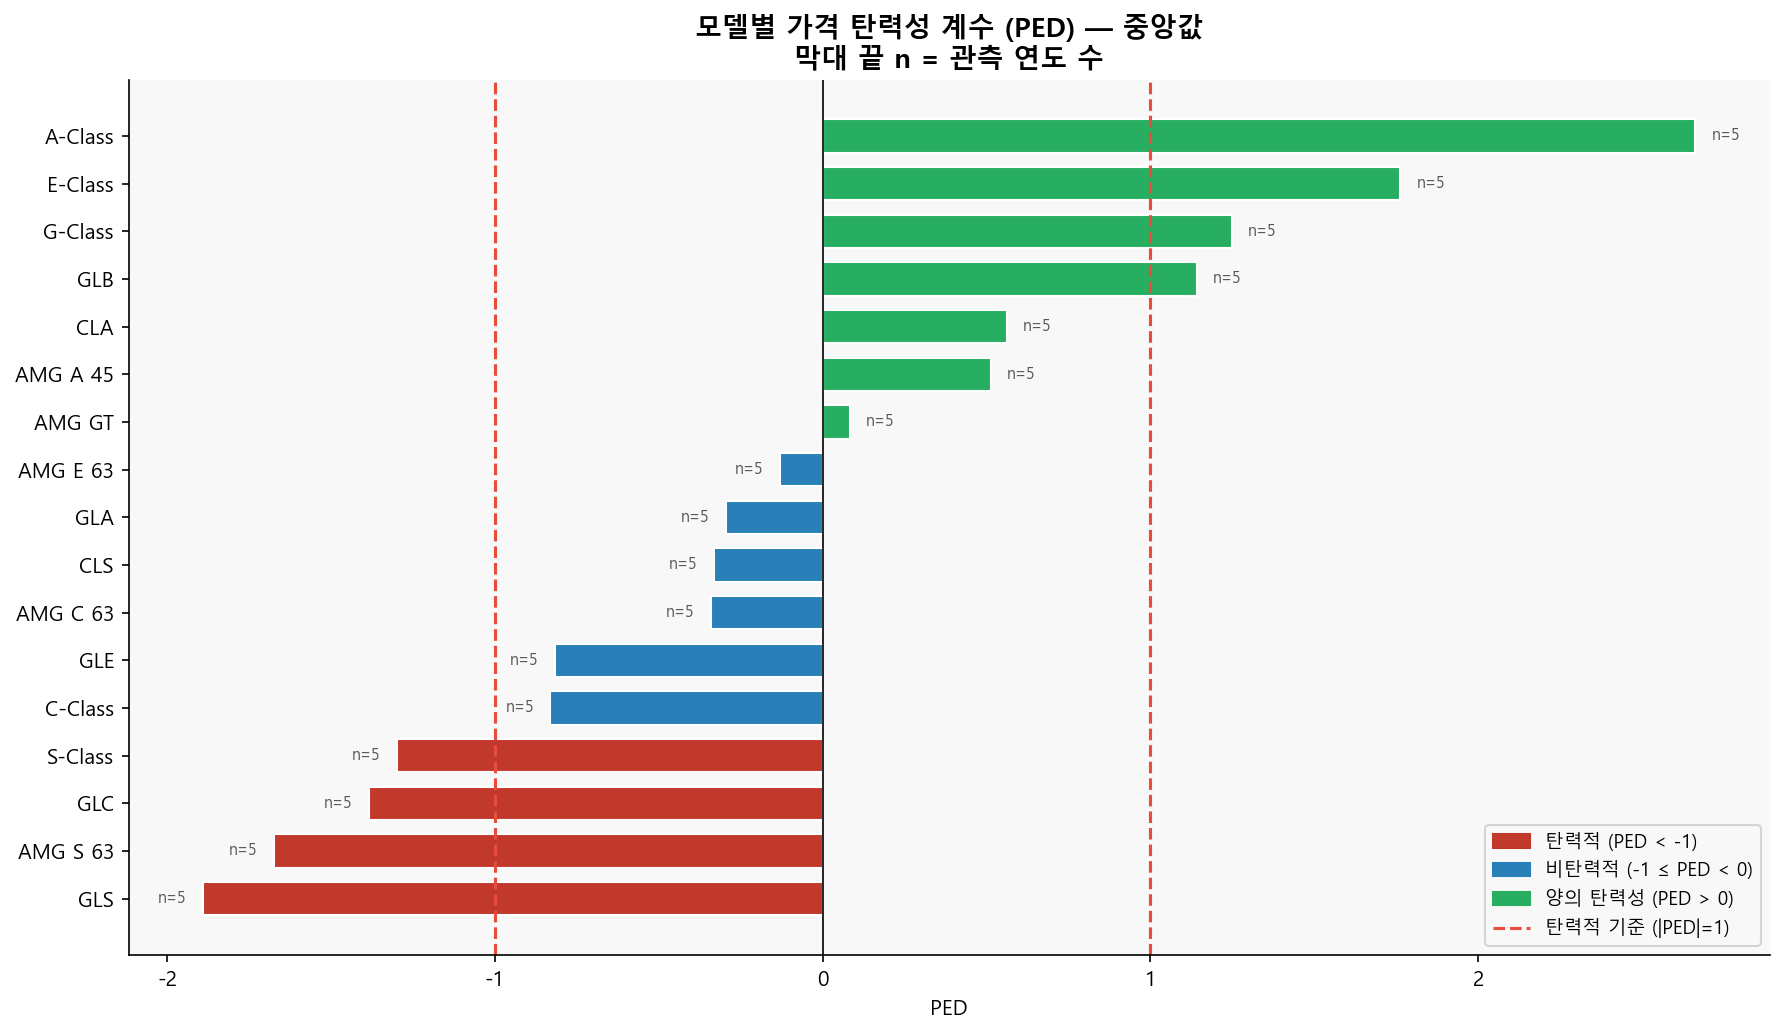

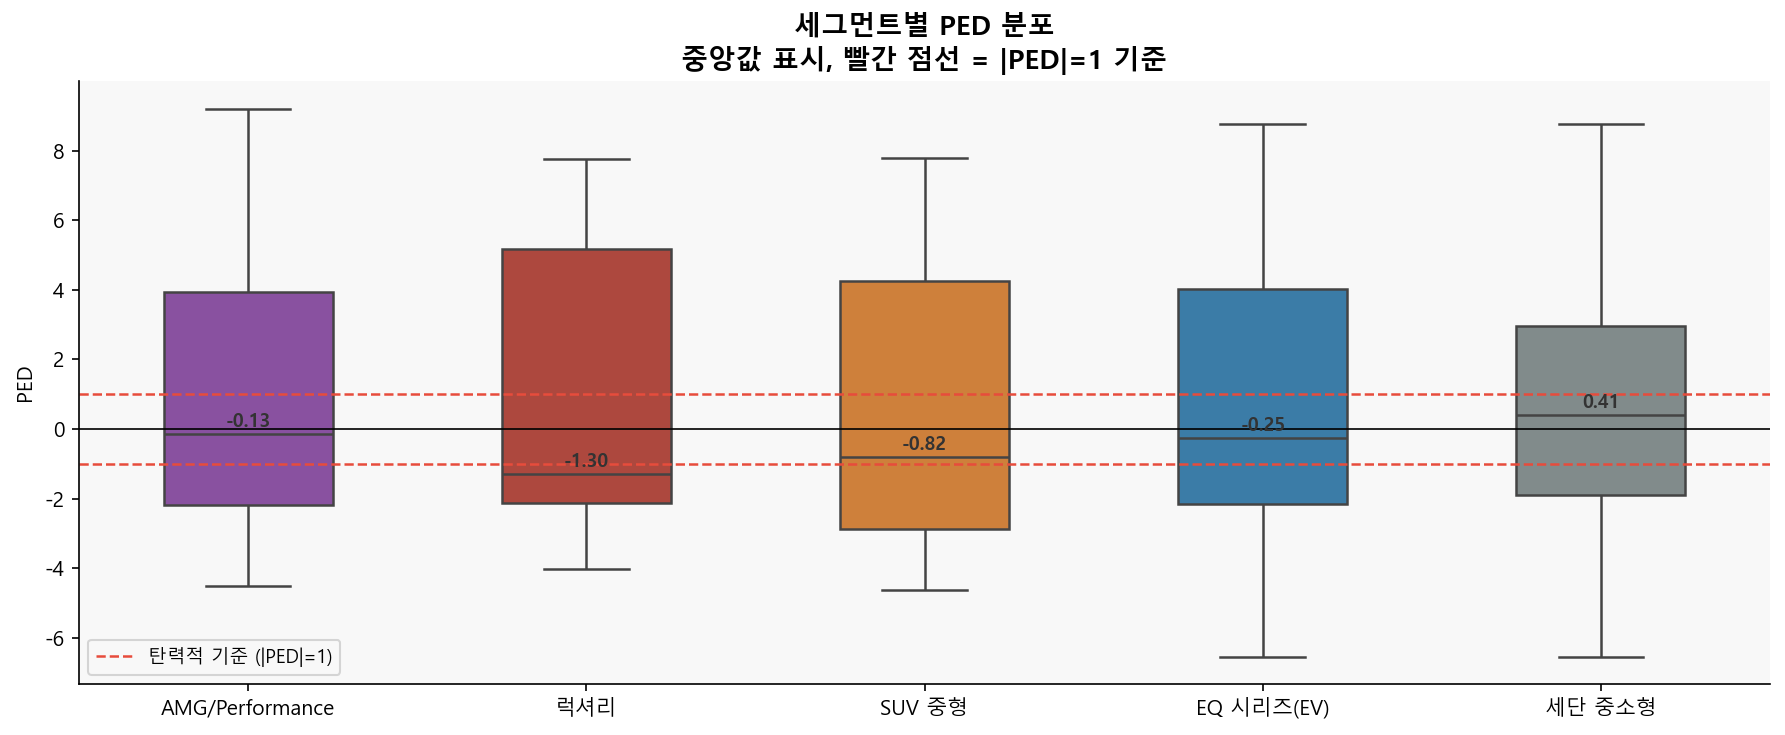

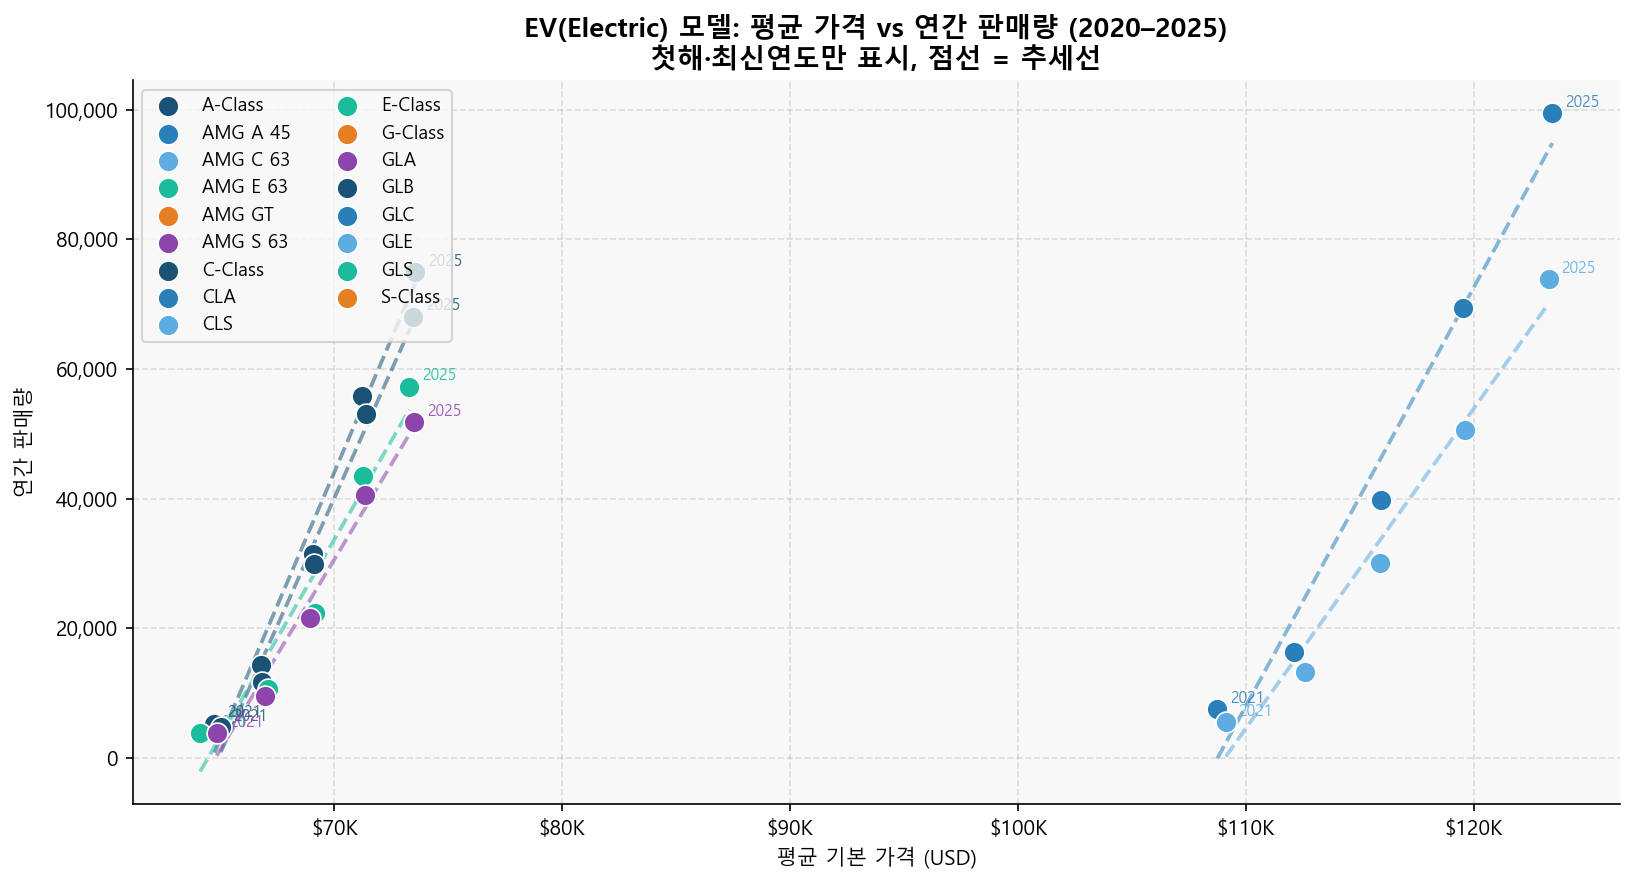

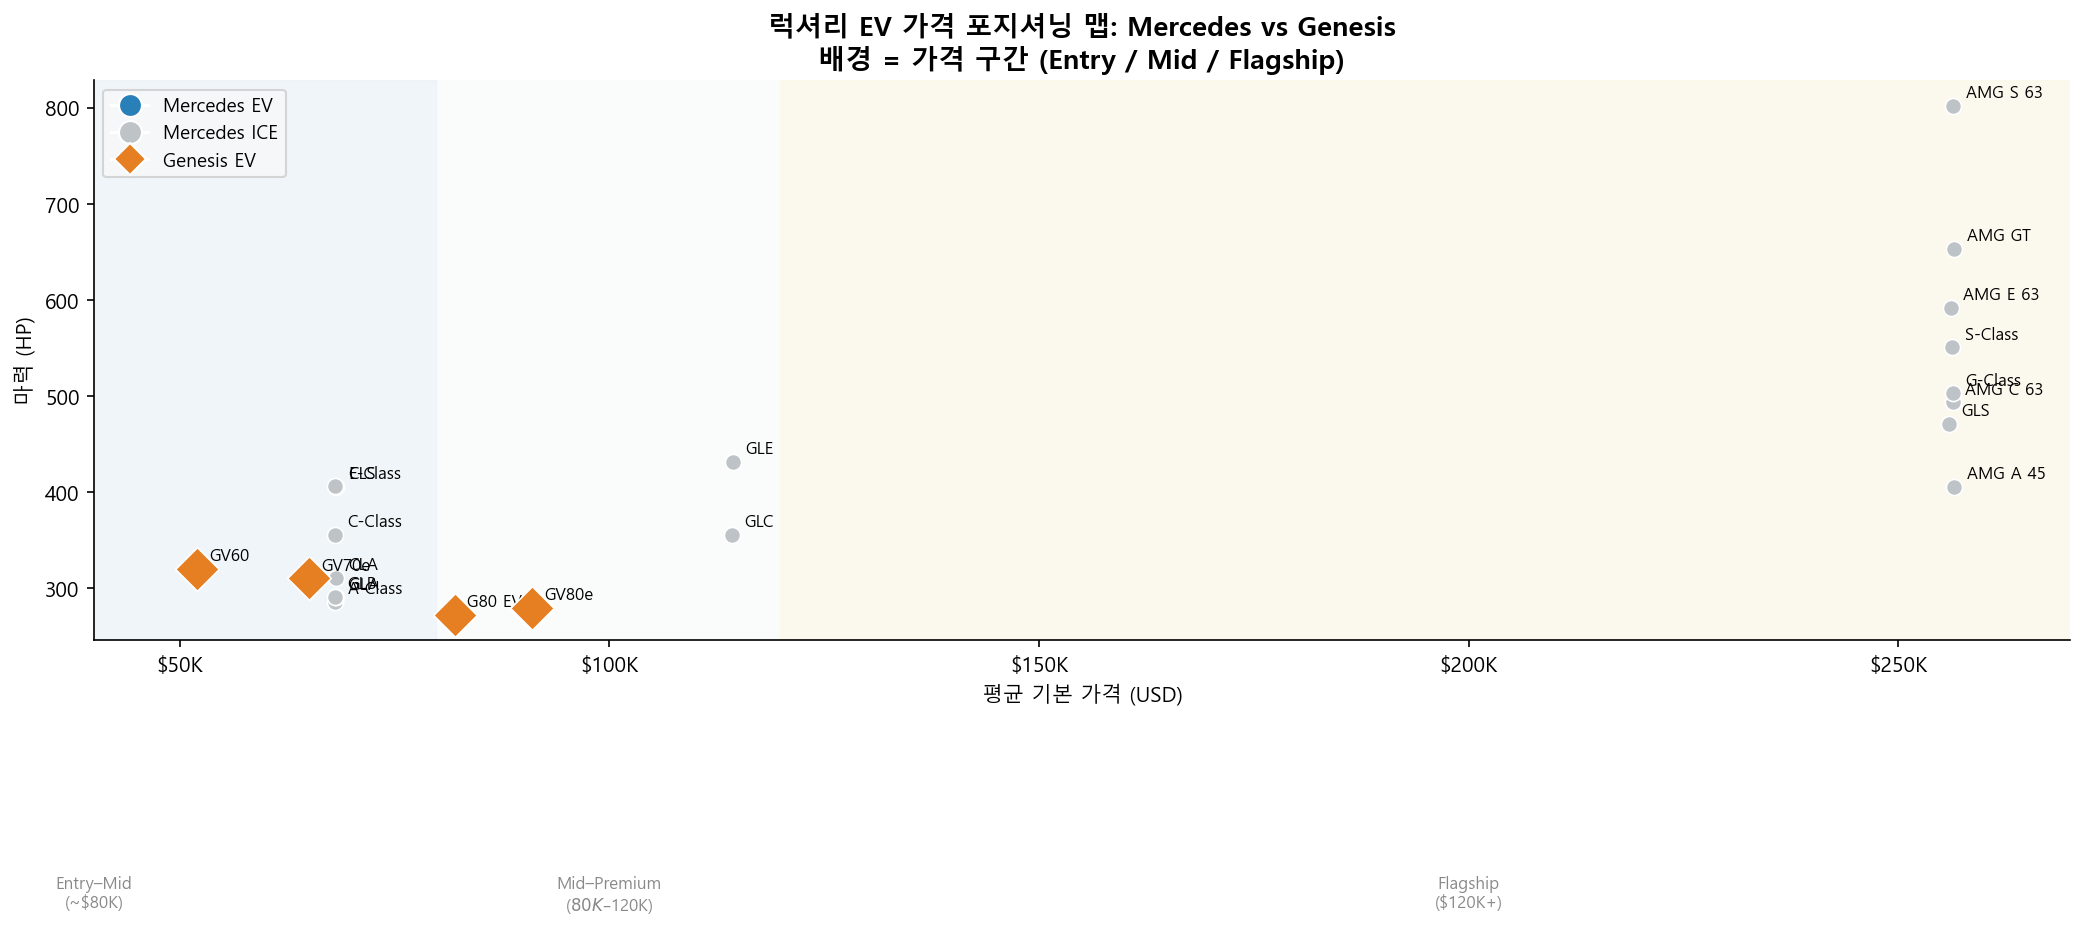


price_elasticity.csv 저장 완료

[세그먼트별 PED 중앙값]
Segment
럭셔리               -1.30
SUV 중형            -0.82
EQ 시리즈(EV)        -0.25
AMG/Performance   -0.13
세단 중소형             0.41

[모델별 PED 상·하위 5개]
── 비탄력적 Top5 (음수, 절댓값 작음) ──
Model
A-Class    2.66
E-Class    1.76
G-Class    1.25
GLB        1.14
CLA        0.56
── 탄력적 Top5 (절댓값 큼) ──
Model
GLS        -1.89
AMG S 63   -1.67
GLC        -1.38
S-Class    -1.30
C-Class    -0.83


In [1]:
# ============================================================
# 03. 가격 탄력성 분석 (Price Elasticity of Demand)
# 핵심 질문: 벤츠 EV는 가격 인상에 판매량이 얼마나 민감한가?
#
# PED = %ΔQ / %ΔP
#   |PED| < 1 → 비탄력적 (프리미엄 수요, 가격 올려도 판매 유지)
#   |PED| > 1 → 탄력적   (가격 민감, 경쟁 노출)
#
# 분석 구성
#   3-1. 모델×연도 집계 및 PED 계산
#   3-2. 모델별 PED 중앙값 (bar)
#   3-3. 세그먼트별 PED 분포 (boxplot)
#   3-4. EV 가격-판매량 산점도 + 회귀선
#   3-5. 가격 포지셔닝 맵 (Mercedes vs Genesis)
#   3-6. 결과 저장
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── 공통 스타일 ───────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "figure.dpi":        150,
})

SAVE = "../outputs/figures/"

# ── 데이터 로드 ───────────────────────────────────────────
df    = pd.read_parquet("../data/processed/mercedes_processed.parquet")
eq_df = pd.read_parquet("../data/processed/eq_series.parquet")

print(f"전체 데이터   : {len(df):,}행")
print(f"EV 데이터     : {len(eq_df):,}행")
print(f"EV 모델 종류  : {eq_df['Model'].nunique()}개")


# ════════════════════════════════════════════════════════
# 3-1. 모델×연도 집계 및 PED 계산
# ════════════════════════════════════════════════════════
price_vol = (
    df.groupby(["Model", "Year"])
    .agg(avg_price=("Base Price (USD)", "mean"),
         volume=("Sales Volume", "sum"))
    .reset_index()
    .sort_values(["Model", "Year"])
)

price_vol["price_chg"]  = price_vol.groupby("Model")["avg_price"].pct_change() * 100
price_vol["volume_chg"] = price_vol.groupby("Model")["volume"].pct_change() * 100
price_vol = price_vol.dropna(subset=["price_chg", "volume_chg"])

# ── 수정: 임계값 0.01% → 0.5% (합성 데이터 과도한 NaN 제거 방지) ──
price_vol["PED"] = np.where(
    price_vol["price_chg"].abs() > 0.5,
    price_vol["volume_chg"] / price_vol["price_chg"],
    np.nan
)
price_vol = price_vol.dropna(subset=["PED"])
price_vol["PED"] = price_vol["PED"].clip(-10, 10)

print(f"\nPED 계산 완료: {len(price_vol):,}개 관측치")
print(price_vol[["Model","Year","avg_price","volume",
                 "price_chg","volume_chg","PED"]].head(10).to_string(index=False))


# ════════════════════════════════════════════════════════
# 3-2. 모델별 PED 중앙값 (수평 막대)
# ════════════════════════════════════════════════════════
ped_model = (
    price_vol.groupby("Model")["PED"]
    .agg(["median", "count"])
    .rename(columns={"median": "PED", "count": "n"})
    .sort_values("PED")
    .reset_index()
)

# 색상: 빨강(탄력적, PED<-1) / 파랑(비탄력적, -1≤PED<0) / 초록(양수)
ped_model["color"] = ped_model["PED"].apply(
    lambda v: "#c0392b" if v < -1 else "#2980b9" if v < 0 else "#27ae60"
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(ped_model["Model"], ped_model["PED"],
               color=ped_model["color"], edgecolor="white", height=0.7)

# 막대 끝에 샘플 수 표시 (신뢰도 확인용)
for bar, n in zip(bars, ped_model["n"]):
    x = bar.get_width()
    ax.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
            f"n={n}", va="center", ha="left" if x >= 0 else "right",
            fontsize=7.5, color="#555")

ax.axvline(0,  color="black",   lw=0.8)
ax.axvline(-1, color="#e74c3c", lw=1.5, ls="--")
ax.axvline(1,  color="#e74c3c", lw=1.5, ls="--", label="탄력적 기준 (|PED|=1)")

legend_patches = [
    mpatches.Patch(color="#c0392b", label="탄력적 (PED < -1)"),
    mpatches.Patch(color="#2980b9", label="비탄력적 (-1 ≤ PED < 0)"),
    mpatches.Patch(color="#27ae60", label="양의 탄력성 (PED > 0)"),
    mlines.Line2D([],[],color="#e74c3c", ls="--", lw=1.5, label="탄력적 기준 (|PED|=1)"),
]
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")
ax.set_title("모델별 가격 탄력성 계수 (PED) — 중앙값\n막대 끝 n = 관측 연도 수")
ax.set_xlabel("PED")
plt.tight_layout()
plt.savefig(f"{SAVE}05_ped_by_model.png", dpi=150, bbox_inches="tight")
plt.show()


# ════════════════════════════════════════════════════════
# 3-3. 세그먼트별 PED 분포 (박스플롯)
# ════════════════════════════════════════════════════════
seg_map = df[["Model", "Segment"]].drop_duplicates()
ped_seg = price_vol.merge(seg_map, on="Model", how="left")

seg_order = [s for s in
             ["AMG/Performance","럭셔리","SUV 중형","EQ 시리즈(EV)","세단 중소형"]
             if s in ped_seg["Segment"].unique()]
seg_palette = dict(zip(seg_order,
                       ["#8e44ad","#c0392b","#e67e22","#2980b9","#7f8c8d"]))

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=ped_seg, x="Segment", y="PED", order=seg_order,
            palette=seg_palette, ax=ax, width=0.5, linewidth=1.2,
            flierprops=dict(marker="o", markersize=4, alpha=0.5))

ax.axhline(0,  color="black",   lw=0.8)
ax.axhline(-1, color="#e74c3c", lw=1.2, ls="--")
ax.axhline(1,  color="#e74c3c", lw=1.2, ls="--", label="탄력적 기준 (|PED|=1)")

# 세그먼트별 중앙값 텍스트 표시
for i, seg in enumerate(seg_order):
    med = ped_seg[ped_seg["Segment"] == seg]["PED"].median()
    ax.text(i, med + 0.2, f"{med:.2f}", ha="center", fontsize=9,
            fontweight="bold", color="#333")

ax.set_title("세그먼트별 PED 분포\n중앙값 표시, 빨간 점선 = |PED|=1 기준")
ax.set_ylabel("PED")
ax.set_xlabel("")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE}06_ped_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()


# ════════════════════════════════════════════════════════
# 3-4. EV 가격-판매량 산점도 + 회귀선
#       수정: 상위 6개 모델만, annotate 겹침 방지, 클러스터 영역 표시
# ════════════════════════════════════════════════════════
eq_top6 = eq_df["Model"].value_counts().head(6).index.tolist()
eq_agg  = (
    eq_df[eq_df["Model"].isin(eq_top6)]
    .groupby(["Model", "Year"])
    .agg(avg_price=("Base Price (USD)", "mean"),
         volume=("Sales Volume", "sum"))
    .reset_index()
)

palette_eq = ["#1a5276","#2980b9","#5dade2","#1abc9c","#e67e22","#8e44ad"]
fig, ax    = plt.subplots(figsize=(11, 6))

for i, (model, grp) in enumerate(eq_agg.groupby("Model")):
    c = palette_eq[i % len(palette_eq)]
    grp = grp.sort_values("Year")

    ax.scatter(grp["avg_price"], grp["volume"],
               label=model, s=100, color=c, zorder=4,
               edgecolors="white", linewidths=0.8)

    # 연도 레이블 (최신·최초 연도만 표시 → 겹침 감소)
    for _, row in grp.iterrows():
        if int(row["Year"]) in [grp["Year"].min(), grp["Year"].max()]:
            ax.annotate(str(int(row["Year"])),
                        (row["avg_price"], row["volume"]),
                        textcoords="offset points", xytext=(6, 3),
                        fontsize=7.5, color=c, alpha=0.85)

    # 회귀선 (3개 이상 포인트)
    if len(grp) >= 3:
        slope, intercept, *_ = stats.linregress(grp["avg_price"], grp["volume"])
        xs = np.linspace(grp["avg_price"].min(), grp["avg_price"].max(), 80)
        ax.plot(xs, slope*xs + intercept, lw=1.8, color=c, ls="--", alpha=0.55)

ax.set_title("EV(Electric) 모델: 평균 가격 vs 연간 판매량 (2020–2025)\n"
             "첫해·최신연도만 표시, 점선 = 추세선")
ax.set_xlabel("평균 기본 가격 (USD)")
ax.set_ylabel("연간 판매량")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9, ncol=2, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{SAVE}07_ev_price_volume.png", dpi=150, bbox_inches="tight")
plt.show()


# ════════════════════════════════════════════════════════
# 3-5. 가격 포지셔닝 맵 — Mercedes EV vs Genesis EV
#       수정: x축 범위 조정, 가격대별 배경 영역 추가
# ════════════════════════════════════════════════════════
pos_df = (
    df.groupby("Model")
    .agg(avg_price=("Base Price (USD)", "mean"),
         avg_hp=("Horsepower", "mean"),
         is_eq=("Is_EQ", "first"))
    .reset_index()
)
pos_df["brand"] = "Mercedes"

genesis = pd.DataFrame({
    "Model":     ["GV60",  "GV70e", "G80 EV", "GV80e"],
    "avg_price": [52_000,  65_000,  82_000,   91_000],
    "avg_hp":    [320,      310,     272,       279],
    "is_eq":     [True,     True,    True,      True],
    "brand":     ["Genesis"] * 4,
})
pos_all = pd.concat([pos_df, genesis], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 7))

# 가격대 배경 영역 (진입/중형/플래그십 구분)
price_bands = [
    (0,      80_000, "#eaf4fb", "Entry–Mid\n(~$80K)"),
    (80_000, 120_000,"#fdfefe", "Mid–Premium\n($80K–$120K)"),
    (120_000,280_000,"#fef9e7", "Flagship\n($120K+)"),
]
for xmin, xmax, fc, label in price_bands:
    ax.axvspan(xmin, xmax, color=fc, alpha=0.6, zorder=0)
    ax.text((xmin+xmax)/2, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 850,
            label, ha="center", va="top", fontsize=8, color="#888", style="italic")

for _, row in pos_all.iterrows():
    if row["brand"] == "Genesis":
        c, s, mk, zord = "#e67e22", 220, "D", 4
    elif row["is_eq"]:
        c, s, mk, zord = "#2980b9", 110, "o", 4
    else:
        c, s, mk, zord = "#bdc3c7", 60,  "o", 3

    ax.scatter(row["avg_price"], row["avg_hp"],
               c=c, s=s, marker=mk, edgecolors="white", lw=0.8, zorder=zord)
    ax.annotate(row["Model"], (row["avg_price"], row["avg_hp"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# 범례
legend_el = [
    mlines.Line2D([],[],marker="o",color="w",markerfacecolor="#2980b9",ms=11,label="Mercedes EV"),
    mlines.Line2D([],[],marker="o",color="w",markerfacecolor="#bdc3c7",ms=11,label="Mercedes ICE"),
    mlines.Line2D([],[],marker="D",color="w",markerfacecolor="#e67e22",ms=11,label="Genesis EV"),
]
ax.legend(handles=legend_el, loc="upper left", fontsize=9)
ax.set_title("럭셔리 EV 가격 포지셔닝 맵: Mercedes vs Genesis\n배경 = 가격 구간 (Entry / Mid / Flagship)")
ax.set_xlabel("평균 기본 가격 (USD)")
ax.set_ylabel("마력 (HP)")
ax.set_xlim(40_000, 270_000)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig(f"{SAVE}08_positioning_map.png", dpi=150, bbox_inches="tight")
plt.show()


# ════════════════════════════════════════════════════════
# 3-6. 결과 저장 및 요약 출력
# ════════════════════════════════════════════════════════
price_vol.to_csv("../data/processed/price_elasticity.csv", index=False)
print("\nprice_elasticity.csv 저장 완료")

print("\n[세그먼트별 PED 중앙값]")
print(ped_seg.groupby("Segment")["PED"].median().round(2).sort_values().to_string())

print("\n[모델별 PED 상·하위 5개]")
summary = ped_model.set_index("Model")["PED"]
print("── 비탄력적 Top5 (음수, 절댓값 작음) ──")
print(summary.sort_values(ascending=False).head(5).round(2).to_string())
print("── 탄력적 Top5 (절댓값 큼) ──")
print(summary.sort_values().head(5).round(2).to_string())